# Nearest-Neighbors Matching with `homework_1.2.csv`

## tl;dr

This notebook reproduces the two matching approaches used in Coding Quiz Week 1:

| Question | Result | Quiz choice |
|---|---:|---|
| Q4: Farthest one-nearest-neighbor distance | **0.210217** | **Option B** |
| Q5: One-neighbor matched effect | **0.543360** | **Option C** |
| Q6: Duplicate radius-match occurrences | **685** | **Option C** |
| Q7: Radius-neighbor effect | **0.584412** | **Option C** |

The effect direction throughout is mean `Y` for `X=1` minus the relevant matched mean `Y` for `X=0`.

## Context & Methods

**Goal:** Match each `X=1` observation to comparable `X=0` observations using the distance between their `Z` values, then calculate the requested outcome differences.

**Source:** `homework_1.2.csv` in the same folder as this notebook.

- **Approach A:** Fit `NearestNeighbors(n_neighbors=1)` on the `X=0` observations and select one closest control for every `X=1` observation. Matching is with replacement.
- **Approach B:** Fit `NearestNeighbors(radius=0.2)` on the controls and retain every control within 0.2 of each treated observation. A control may appear in more than one treated observation's neighbor group.
- Because `Z` is one-dimensional, Euclidean distance is simply the absolute difference between two `Z` values.

### Key Assumptions

- `X=1` is treated and `X=0` is control.
- The quiz defines the effect as treated mean minus matched-control mean.
- For Question 7, the mean control outcome is calculated for each non-empty neighbor group, then those group means are averaged. The quiz result retains the full `X=1` mean even though two treated observations have no radius neighbor; a matched-only sensitivity result is also shown.
- Matching on `Z` only addresses observed differences in `Z`. It does not, by itself, prove a causal effect.

## Data

### 1. Set up the analysis

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.neighbors import NearestNeighbors

DATA_PATH = Path("homework_1.2.csv")
REQUIRED_COLUMNS = ["X", "Y", "Z"]
TREATED_VALUE = 1
CONTROL_VALUE = 0
MATCH_RADIUS = 0.2

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.edgecolor": "#374151",
    "axes.labelcolor": "#1F2937",
    "text.color": "#1F2937",
    "xtick.color": "#4B5563",
    "ytick.color": "#4B5563",
    "grid.color": "#E5E7EB",
})

BLUE = "#2563EB"
GOLD = "#D99A2B"
DARK = "#374151"
LIGHT_BLUE = "#93C5FD"

### 2. Load and validate the CSV

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Place the CSV in the notebook's working directory."
    )

data = pd.read_csv(DATA_PATH).reset_index(names="row_id")

missing_columns = [column for column in REQUIRED_COLUMNS if column not in data.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if not all(pd.api.types.is_numeric_dtype(data[column]) for column in REQUIRED_COLUMNS):
    raise TypeError("X, Y, and Z must all be numeric.")

if data[REQUIRED_COLUMNS].isna().any().any():
    raise ValueError("Missing values are present in X, Y, or Z.")

observed_x_values = set(data["X"].unique())
if observed_x_values != {CONTROL_VALUE, TREATED_VALUE}:
    raise ValueError(f"Expected X to contain only 0 and 1; found {observed_x_values}.")

treated = data.loc[data["X"] == TREATED_VALUE].copy().reset_index(drop=True)
controls = data.loc[data["X"] == CONTROL_VALUE].copy().reset_index(drop=True)

audit = pd.DataFrame({
    "Check": ["Rows", "Controls (X=0)", "Treated (X=1)", "Missing values", "Duplicate rows"],
    "Result": [
        f"{len(data):,}",
        f"{len(controls):,}",
        f"{len(treated):,}",
        f"{int(data[REQUIRED_COLUMNS].isna().sum().sum()):,}",
        f"{int(data[REQUIRED_COLUMNS].duplicated().sum()):,}",
    ],
})

display(audit)
display(data[REQUIRED_COLUMNS].head().round(4))

,Check,Result
0,Rows,100
1,Controls (X=0),52
2,Treated (X=1),48
3,Missing values,0
4,Duplicate rows,0


,X,Y,Z
0,0,0.5488,0.5488
1,1,1.2152,0.7152
2,0,0.6028,0.6028
3,0,0.5449,0.5449
4,0,0.4237,0.4237


### 3. Inspect overlap in the matching variable

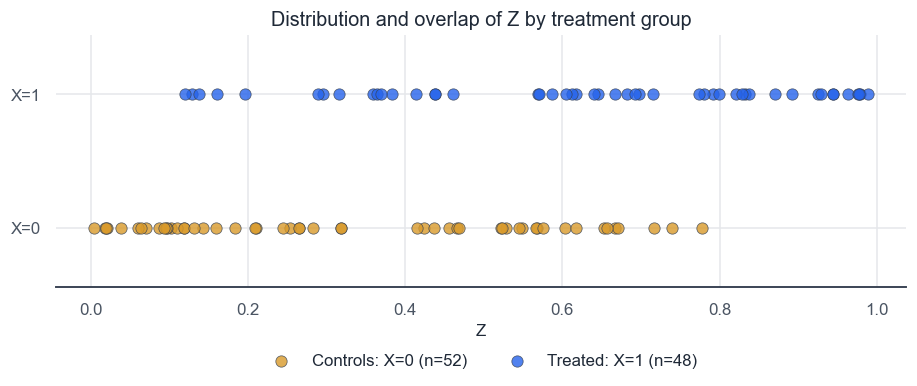

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))

ax.scatter(
    controls["Z"],
    np.zeros(len(controls)),
    s=55,
    color=GOLD,
    edgecolor=DARK,
    linewidth=0.5,
    alpha=0.8,
    label=f"Controls: X=0 (n={len(controls)})",
)
ax.scatter(
    treated["Z"],
    np.ones(len(treated)),
    s=55,
    color=BLUE,
    edgecolor=DARK,
    linewidth=0.5,
    alpha=0.8,
    label=f"Treated: X=1 (n={len(treated)})",
)

ax.set_title("Distribution and overlap of Z by treatment group")
ax.set_xlabel("Z")
ax.set_ylabel("")
ax.set_yticks([0, 1], ["X=0", "X=1"])
ax.set_ylim(-0.45, 1.45)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

The groups overlap across much of the `Z` range, but the highest treated `Z` values have limited control support. This produces the largest nearest-neighbor distance and two empty radius groups later in the analysis.

## Results

### 4. Approach A — select one nearest control

In [4]:
one_neighbor_model = NearestNeighbors(n_neighbors=1)
one_neighbor_model.fit(controls[["Z"]])

nearest_distances, nearest_positions = one_neighbor_model.kneighbors(treated[["Z"]])
nearest_distances = nearest_distances.ravel()
nearest_positions = nearest_positions.ravel()
matched_controls = controls.iloc[nearest_positions].reset_index(drop=True)

one_neighbor_matches = pd.DataFrame({
    "treated_row": treated["row_id"],
    "treated_Z": treated["Z"],
    "treated_Y": treated["Y"],
    "control_row": matched_controls["row_id"],
    "control_Z": matched_controls["Z"],
    "control_Y": matched_controls["Y"],
    "distance": nearest_distances,
})
one_neighbor_matches["treated_minus_control_Y"] = (
    one_neighbor_matches["treated_Y"] - one_neighbor_matches["control_Y"]
)

# In one dimension, the returned Euclidean distance must equal |treated Z - control Z|.
np.testing.assert_allclose(
    one_neighbor_matches["distance"],
    (one_neighbor_matches["treated_Z"] - one_neighbor_matches["control_Z"]).abs(),
)

farthest_match_distance = one_neighbor_matches["distance"].max()
treated_mean_y = treated["Y"].mean()
matched_control_mean_y = one_neighbor_matches["control_Y"].mean()
one_neighbor_effect = treated_mean_y - matched_control_mean_y

approach_a_summary = pd.DataFrame({
    "Measure": [
        "Treated observations",
        "Unique controls selected",
        "Farthest match distance (Q4)",
        "Mean Y, treated",
        "Mean Y, matched controls",
        "Effect: treated − matched control (Q5)",
    ],
    "Value": [
        len(treated),
        one_neighbor_matches["control_row"].nunique(),
        farthest_match_distance,
        treated_mean_y,
        matched_control_mean_y,
        one_neighbor_effect,
    ],
})

display(approach_a_summary.style.format({"Value": "{:.6f}"}))
display(
    one_neighbor_matches.nlargest(8, "distance").style.format({
        "treated_Z": "{:.6f}",
        "treated_Y": "{:.6f}",
        "control_Z": "{:.6f}",
        "control_Y": "{:.6f}",
        "distance": "{:.6f}",
        "treated_minus_control_Y": "{:.6f}",
    })
)

,Measure,Value
0,Treated observations,48.000000
1,Unique controls selected,20.000000
2,Farthest match distance (Q4),0.210217
3,"Mean Y, treated",1.125597
4,"Mean Y, matched controls",0.582237
5,Effect: treated − matched control (Q5),0.543360


,treated_row,treated_Z,treated_Y,control_row,control_Z,control_Y,distance,treated_minus_control_Y
29,52,0.988374,1.488374,18,0.778157,0.778157,0.210217,0.710217
10,20,0.978618,1.478618,18,0.778157,0.778157,0.200462,0.700462
37,72,0.976761,1.476761,18,0.778157,0.778157,0.198604,0.698604
36,70,0.976459,1.476459,18,0.778157,0.778157,0.198303,0.698303
4,8,0.963663,1.463663,18,0.778157,0.778157,0.185506,0.685506
15,27,0.944669,1.444669,18,0.778157,0.778157,0.166512,0.666512
20,38,0.943748,1.443748,18,0.778157,0.778157,0.165591,0.665591
43,89,0.929296,1.429296,18,0.778157,0.778157,0.151139,0.651139


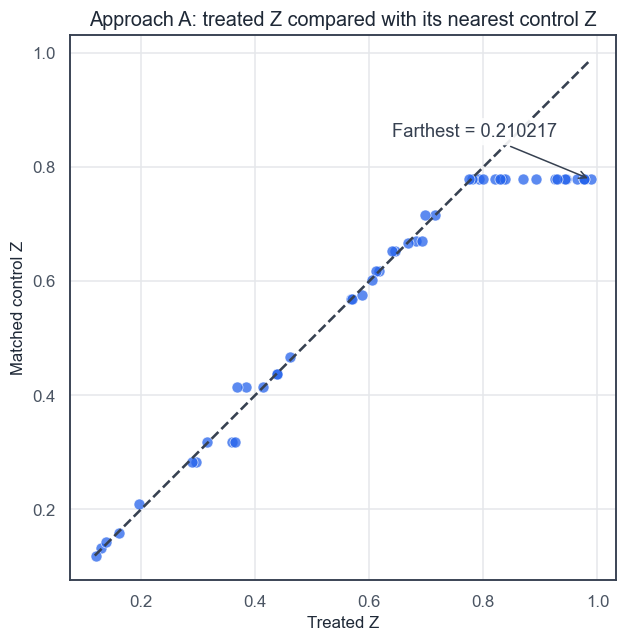

In [5]:
z_min = min(one_neighbor_matches["treated_Z"].min(), one_neighbor_matches["control_Z"].min())
z_max = max(one_neighbor_matches["treated_Z"].max(), one_neighbor_matches["control_Z"].max())

fig, ax = plt.subplots(figsize=(7.2, 6.0))
ax.scatter(
    one_neighbor_matches["treated_Z"],
    one_neighbor_matches["control_Z"],
    s=52,
    color=BLUE,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.75,
)
ax.plot([z_min, z_max], [z_min, z_max], color=DARK, linestyle="--", linewidth=1.7)

farthest_row = one_neighbor_matches.loc[one_neighbor_matches["distance"].idxmax()]
ax.annotate(
    f"Farthest = {farthest_row['distance']:.6f}",
    xy=(farthest_row["treated_Z"], farthest_row["control_Z"]),
    xytext=(-130, 28),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": DARK},
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "none", "alpha": 0.9},
    color=DARK,
)

ax.set_title("Approach A: treated Z compared with its nearest control Z")
ax.set_xlabel("Treated Z")
ax.set_ylabel("Matched control Z")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

Approach A selects one control for each of the 48 treated observations. Only 20 distinct controls are used because matching is with replacement. The farthest distance is **0.210217**, and the treated-minus-matched-control outcome difference is **0.543360**.

### 5. Approach B — retain every control within radius 0.2

In [6]:
radius_model = NearestNeighbors(radius=MATCH_RADIUS)
radius_model.fit(controls[["Z"]])

radius_distances, radius_positions = radius_model.radius_neighbors(
    treated[["Z"]],
    radius=MATCH_RADIUS,
    return_distance=True,
    sort_results=True,
)

group_rows = []
for treated_position, (distances, positions) in enumerate(zip(radius_distances, radius_positions)):
    control_mean_y = controls.iloc[positions]["Y"].mean() if len(positions) else np.nan
    group_rows.append({
        "treated_position": treated_position,
        "treated_row": treated.loc[treated_position, "row_id"],
        "treated_Z": treated.loc[treated_position, "Z"],
        "treated_Y": treated.loc[treated_position, "Y"],
        "neighbor_count": len(positions),
        "control_group_mean_Y": control_mean_y,
    })

radius_groups = pd.DataFrame(group_rows)
radius_groups["group_effect"] = (
    radius_groups["treated_Y"] - radius_groups["control_group_mean_Y"]
)

all_radius_control_positions = np.concatenate(radius_positions)
all_radius_control_rows = controls.iloc[all_radius_control_positions]["row_id"].reset_index(drop=True)

total_radius_matches = len(all_radius_control_rows)
unique_radius_controls = all_radius_control_rows.nunique()
duplicate_radius_matches = int(all_radius_control_rows.duplicated().sum())

# Reconcile the quiz's definition: all but the first occurrence of each reused control.
assert duplicate_radius_matches == total_radius_matches - unique_radius_controls

nonempty_control_group_mean_y = radius_groups["control_group_mean_Y"].mean()
radius_quiz_effect = treated_mean_y - nonempty_control_group_mean_y
matched_only_effect = radius_groups["group_effect"].mean()

approach_b_summary = pd.DataFrame({
    "Measure": [
        "Treated observations",
        "Non-empty neighbor groups",
        "Empty neighbor groups",
        "Total control-match occurrences",
        "Unique controls used",
        "Duplicate occurrences (Q6)",
        "Mean Y, treated (all X=1)",
        "Mean of non-empty control-group mean Y",
        "Quiz effect: treated − group-mean control (Q7)",
        "Matched-only sensitivity effect",
    ],
    "Value": [
        len(treated),
        int((radius_groups["neighbor_count"] > 0).sum()),
        int((radius_groups["neighbor_count"] == 0).sum()),
        total_radius_matches,
        unique_radius_controls,
        duplicate_radius_matches,
        treated_mean_y,
        nonempty_control_group_mean_y,
        radius_quiz_effect,
        matched_only_effect,
    ],
})

display(approach_b_summary.style.format({"Value": "{:.6f}"}))
display(
    radius_groups.loc[radius_groups["neighbor_count"] == 0].style.format({
        "treated_Z": "{:.6f}",
        "treated_Y": "{:.6f}",
        "control_group_mean_Y": "{:.6f}",
        "group_effect": "{:.6f}",
    })
)

,Measure,Value
0,Treated observations,48.000000
1,Non-empty neighbor groups,46.000000
2,Empty neighbor groups,2.000000
3,Total control-match occurrences,737.000000
4,Unique controls used,52.000000
5,Duplicate occurrences (Q6),685.000000
6,"Mean Y, treated (all X=1)",1.125597
7,Mean of non-empty control-group mean Y,0.541185
8,Quiz effect: treated − group-mean control (Q7),0.584412
9,Matched-only sensitivity effect,0.568852


,treated_position,treated_row,treated_Z,treated_Y,neighbor_count,control_group_mean_Y,group_effect
10,10,20,0.978618,1.478618,0,nan,nan
29,29,52,0.988374,1.488374,0,nan,nan


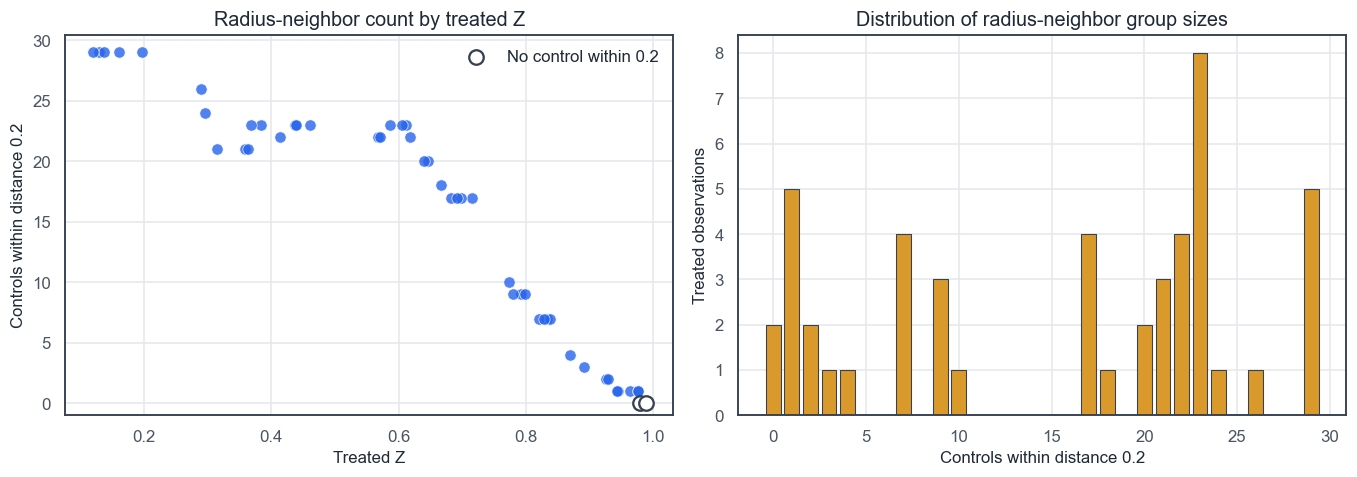

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

axes[0].scatter(
    radius_groups["treated_Z"],
    radius_groups["neighbor_count"],
    s=55,
    color=BLUE,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.8,
)
empty_groups = radius_groups.loc[radius_groups["neighbor_count"] == 0]
axes[0].scatter(
    empty_groups["treated_Z"],
    empty_groups["neighbor_count"],
    s=90,
    facecolor="white",
    edgecolor=DARK,
    linewidth=1.5,
    label="No control within 0.2",
)
axes[0].set_title("Radius-neighbor count by treated Z")
axes[0].set_xlabel("Treated Z")
axes[0].set_ylabel("Controls within distance 0.2")
axes[0].set_ylim(bottom=-1)
axes[0].legend(frameon=False)

count_frequency = radius_groups["neighbor_count"].value_counts().sort_index()
axes[1].bar(
    count_frequency.index,
    count_frequency.values,
    color=GOLD,
    edgecolor=DARK,
    linewidth=0.7,
)
axes[1].set_title("Distribution of radius-neighbor group sizes")
axes[1].set_xlabel("Controls within distance 0.2")
axes[1].set_ylabel("Treated observations")
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

Approach B creates 737 control-match occurrences involving all 52 controls. Counting all but the first occurrence of each reused control gives **685 duplicates**. Forty-six treated observations have a non-empty group; the two highest-`Z` treated observations have none. Following the quiz calculation, the effect is **0.584412**. Restricting both sides to the 46 matched treated observations gives **0.568852**, shown as a sensitivity check rather than the quiz answer.

### 6. Collect the quiz answers

In [8]:
quiz_answers = pd.DataFrame({
    "Question": ["Q4", "Q5", "Q6", "Q7"],
    "Computed result": [
        farthest_match_distance,
        one_neighbor_effect,
        duplicate_radius_matches,
        radius_quiz_effect,
    ],
    "Closest option": [
        "Option B — 0.210217",
        "Option C — 0.54336",
        "Option C — 685",
        "Option C — 0.5844",
    ],
})

display(quiz_answers.style.format({"Computed result": "{:.6f}"}))

,Question,Computed result,Closest option
0,Q4,0.210217,Option B — 0.210217
1,Q5,0.543360,Option C — 0.54336
2,Q6,685.000000,Option C — 685
3,Q7,0.584412,Option C — 0.5844


## Takeaways

- **Question 4:** Option B — the farthest one-neighbor match distance is **0.210217**.
- **Question 5:** Option C — the one-neighbor treated-minus-control effect is **0.543360**.
- **Question 6:** Option C — radius matching yields **685** duplicate control occurrences.
- **Question 7:** Option C — averaging the non-empty control-group means and comparing that value with the full treated mean gives **0.584412**.
- The two empty radius groups are a meaningful overlap limitation. The matching results are descriptive unless the assumptions needed for causal identification are justified separately.